In [41]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import json

from matplotlib import colors
from matplotlib.colors import LogNorm

import pandas as pd

import torch

In [42]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [43]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [44]:
mean_vals = False

data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_validation_2283_corrected'

method = "interp"

M_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_M.nc'))
bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_bl.nc'))
wb_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_wb_dataset.nc'))
bl_tke_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_tke_bl.nc'))
SS_profile_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_S2_sigma_{method}.nc'))
NN_profile_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_N2_sigma_{method}.nc'))
tke_profile_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_tke_sigma_{method}.nc'))
eps_profile_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_eps_sigma_{method}.nc'))

with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

In [45]:
rho0 = 1027
g = 9.81
alpha = 2e-4
cp = 4e3

heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
coriolis_freqs = np.array([calculate_f(case['lat']) for case in gotm_case_dict.values()])
u_stars = np.array([(case['tx'] / rho0) ** 0.5 for case in gotm_case_dict.values()])
taus = np.array([case['tx'] for case in gotm_case_dict.values()])

taus_mask = np.where(taus > 0.005)

Bs = g * alpha * heat_fluxes / (rho0 * cp)

n_cases, t_timesteps = M_data.M[taus_mask].values[:,:-1].shape

Ms = M_data.M[taus_mask].values[:,:-1].flatten()
dMs = (M_data.M[taus_mask].values[:,1:] - M_data.M[taus_mask].values[:,:-1]).flatten()
bls = bl_data.bl[taus_mask].values[:,:-1].flatten()
tke_bls = -bl_tke_data.where(np.isfinite(bl_tke_data.bl),-1.).bl[taus_mask].values[:,:-1].flatten()
wbs = wb_data.wb[taus_mask].values[:,:-1].flatten()

coriolis_freqs = np.repeat(coriolis_freqs, t_timesteps)
u_stars = np.repeat(u_stars, t_timesteps)
taus = np.repeat(taus, t_timesteps)
Bs = np.repeat(Bs, t_timesteps)

In [46]:
t_timesteps

432

In [30]:
Ms.shape

(93312,)

In [31]:
dMs.shape

(93312,)

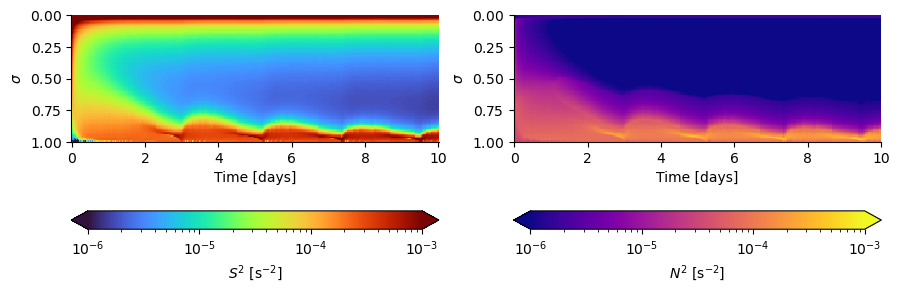

In [ ]:
time, depth = SS_profile_data.time.values, SS_profile_data.sigma_depth.values
Sh2 = SS_profile_data.SS.isel(case=100).T.values
N2 = NN_profile_data.NN.isel(case=100).T.values
time_days = np.linspace(0, 10, len(time)) 

fig, ax = plt.subplots(1,2, figsize=(9,3), tight_layout=True, sharex=True)

c1 = ax[1].pcolor(time_days, depth[::-1], N2, norm=LogNorm(vmin=1e-6, vmax=1e-3), cmap="plasma")
plt.colorbar(c1, ax=ax[1], label="$N^2$ [s$^{-2}$]", orientation="horizontal", ticks=[1e-6, 1e-5, 1e-4, 1e-3], extend="both", pad=0.3)
ax[1].set_ylabel(r"$\sigma$")
# ax[1].set_yticks([0, 50, 100, 150])

c2 = ax[0].pcolor(time_days, depth[::-1], Sh2, norm=LogNorm(vmin=1e-6, vmax=1e-3), cmap="turbo")
plt.colorbar(c2, ax=ax[0], label="$S^2$ [s$^{-2}$]", orientation="horizontal", ticks=[1e-6, 1e-5, 1e-4, 1e-3], extend="both", pad=0.3)
# ax[0].set_ylim(150,0)
ax[0].set_ylabel(r"$\sigma$")
plt.tight_layout()

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.set_ylim(1,0)
    a.set_xlabel("Time [days]")
    a.spines['right'].set_visible(False)
    a.ticklabel_format(style='sci', useMathText=True, scilimits=(-3, 3), axis='y')

plt.savefig("N2_Sh2_sigma_profiles.png", dpi=1500)

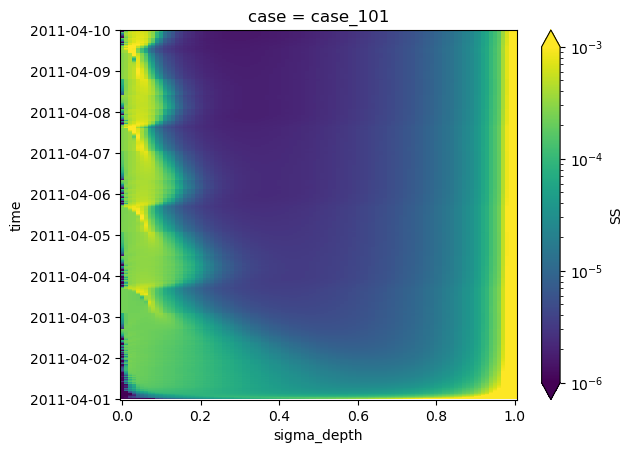

In [32]:
SS_profile_data.SS.isel(case=100).plot(norm=LogNorm(vmin=1e-6, vmax=1e-3))

In [33]:
sigma_depth = SS_profile_data.sigma_depth.values
SS_profiles = {f"SS_sig_{sigma_depth[i]:.2f}": SS_profile_data.SS[taus_mask].values[:,:-1,i].flatten() for i in range(len(sigma_depth))}

In [34]:
sigma_depth = NN_profile_data.sigma_depth.values
NN_profiles = {f"NN_sig_{sigma_depth[i]:.2f}": NN_profile_data.NN[taus_mask].values[:,:-1,i].flatten() for i in range(len(sigma_depth))}

In [35]:
sigma_depth = tke_profile_data.sigma_depth.values
tke_profiles = {f"tke_sig_{sigma_depth[i]:.2f}": tke_profile_data.tke[taus_mask].values[:,:-1,i].flatten() for i in range(len(sigma_depth))}

In [36]:
sigma_depth = eps_profile_data.sigma_depth.values
eps_profiles = {f"eps_sig_{sigma_depth[i]:.2f}": eps_profile_data.eps[taus_mask].values[:,:-1,i].flatten() for i in range(len(sigma_depth))}

In [37]:
data_dict = {"M": Ms, "dM": dMs, "f": coriolis_freqs, "u_star": u_stars, "B": Bs, "bl_rh18": bls, "bl_tke": tke_bls, "wb": wbs}

In [38]:
data_dict.update(SS_profiles)
data_dict.update(NN_profiles)
data_dict.update(tke_profiles)
data_dict.update(eps_profiles)

In [39]:
# make sure no std = 0 -> not possible to normalize

data_dict_cleared = data_dict.copy()

for key, value in data_dict.items():
    if np.std(value) == 0.:
        data_dict_cleared.pop(key)
    else:
        pass

In [40]:
df = pd.DataFrame(data_dict_cleared)
df.to_csv(os.path.join(data_directory, f'{dataset_name}_features_and_targets_101sig_even_{method}_with_dM.csv'), index=False)

In [79]:
df

,M,f,u_star,B,bl_rh18,bl_tke,wb,SS_sig_0.00,SS_sig_0.01,SS_sig_0.02,...,NN_sig_0.90,NN_sig_0.91,NN_sig_0.92,NN_sig_0.93,NN_sig_0.94,NN_sig_0.95,NN_sig_0.96,NN_sig_0.97,NN_sig_0.98,NN_sig_0.99
0,2.877826e-07,0.000038,0.015602,-4.298442e-08,14.0,15.084186,-4.117939e-08,2.137218e-11,1.982633e-08,5.943626e-08,...,-3.661626e-06,-4.130142e-06,-5.067174e-06,-5.535690e-06,-5.185308e-06,-0.000005,-0.000003,-0.000003,-0.000002,-6.481635e-07
1,6.135767e-07,0.000038,0.015602,-4.298442e-08,19.0,20.866898,-5.474299e-08,6.261421e-10,9.283286e-08,2.772463e-07,...,-2.018905e-06,-2.616475e-06,-3.811616e-06,-4.409187e-06,-5.006757e-06,-0.000006,-0.000004,-0.000004,-0.000003,-8.966770e-07
2,8.995112e-07,0.000038,0.015602,-4.298442e-08,24.0,24.994547,-6.550884e-08,6.389163e-08,6.318927e-07,1.767895e-06,...,-1.685105e-06,-1.944489e-06,-2.871735e-06,-3.576732e-06,-4.281729e-06,-0.000005,-0.000006,-0.000004,-0.000003,-1.112720e-06
3,1.145512e-06,0.000038,0.015602,-4.298442e-08,28.0,28.995445,-7.772172e-08,8.119390e-08,8.058346e-07,2.255116e-06,...,-1.344905e-06,-1.640023e-06,-2.230260e-06,-2.711140e-06,-3.526393e-06,-0.000004,-0.000006,-0.000005,-0.000004,-1.332500e-06
4,1.355858e-06,0.000038,0.015602,-4.298442e-08,31.0,32.954956,-8.779426e-08,5.326514e-09,3.502740e-07,1.040169e-06,...,-1.080993e-06,-1.299455e-06,-1.964377e-06,-2.296838e-06,-2.740727e-06,-0.000004,-0.000006,-0.000006,-0.000005,-1.553788e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93091,5.208164e-06,0.000145,0.030414,4.298442e-08,89.0,89.996323,0.000000e+00,1.851324e-03,4.312366e-03,2.235326e-04,...,6.257153e-07,6.800831e-07,7.507786e-07,8.460657e-07,9.809386e-07,0.000001,0.000001,0.000002,0.000002,4.047068e-06
93092,5.192424e-06,0.000145,0.030414,4.298442e-08,89.0,89.998123,0.000000e+00,2.322699e-03,3.857170e-03,1.866997e-04,...,6.258005e-07,6.801655e-07,7.508581e-07,8.461422e-07,9.810120e-07,0.000001,0.000001,0.000002,0.000002,4.047124e-06
93093,5.180957e-06,0.000145,0.030414,4.298442e-08,89.0,89.999413,0.000000e+00,2.751038e-03,3.335290e-03,1.506863e-04,...,6.258411e-07,6.802041e-07,7.508948e-07,8.461768e-07,9.810442e-07,0.000001,0.000001,0.000002,0.000002,4.047144e-06
93094,5.176315e-06,0.000145,0.030414,4.298442e-08,89.0,90.544380,0.000000e+00,7.759021e-06,3.061935e-03,2.737231e-03,...,6.204890e-07,6.740190e-07,7.436036e-07,8.373387e-07,9.698840e-07,0.000001,0.000001,0.000002,0.000002,4.092612e-06
